Notebook to perform additional experiments with alternative approaches to absolute maximum common-edge subgraph (MCES) molecular distances for the error function.

The experiments were performed using the CCS model GraphCCS.

Environments:
- base
    - python 3.12.7
    - scikit-learn 1.7.1
    - matplotlib 3.10.0
- Keras
    - python 3.12.9
    - keras 3.9.2
    - scikit-learn 1.6.1
    - matplotlib 3.10.0
- cvxpy
    - python 3.13.9
    - cvxpy 1.7.2
    - matplotlib 3.10.8

# Normalized MCES distances

In [ ]:
# base


import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt

In [27]:
Ucal = np.load('CALmyopicMCES.npy') # calibration MCES distance matrix 
print(f'Calibration MCES distance matrix: {Ucal.shape}')
normUcal = np.load('CALmyopicMCESnorm.npy') # calibration normalized MCES distance matrix 
print(f'Calibration normalized MCES distance matrix: {normUcal.shape}')

Calibration MCES distance matrix: (5805, 6668)
Calibration normalized MCES distance matrix: (5805, 6668)


In [28]:
mces_cal = np.mean(np.partition(Ucal, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)
mces_cal.shape

(5805,)

In [37]:
y_hat_cal = np.load('y_hat_cal.npy') # CCS prediction for the final calibrants from the final GraphCCS model
print(f'Number of final GraphCCS calibration predictions: {y_hat_cal.size}')

with open("final_fold_idxs.pkl", 'rb') as f:
    final_fold = pickle.load(f) # tuple of two arrays with the indexes of METLIN-CCS for the final training and calibration splits
print(f'Size of training set: {final_fold[0].size} --- Size of calibration set: {final_fold[1].size}')
clean_metlin = pd.read_csv('METLINclean.csv')
abs_errors = np.abs(clean_metlin.CCS.iloc[final_fold[1]] - y_hat_cal).to_numpy()

Number of final GraphCCS calibration predictions: 5805
Size of training set: 52236 --- Size of calibration set: 5805


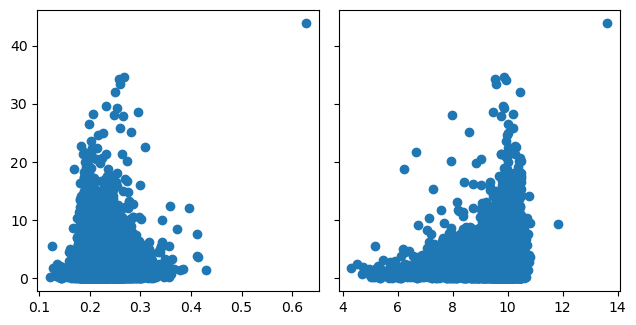

In [36]:
norm_mces_cal = np.mean(np.partition(normUcal, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)
norm_mces_cal.shape

fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(norm_mces_cal, abs_errors)
axes[1].scatter(mces_cal, abs_errors)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

# Variance/standard deviation of ensemble

## 5x5 cross-validation

In [ ]:
# base


import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt

In [39]:
YhatCVcal = np.load('YhatCVcal.npy') # CCS prediction for the final calibrants from the 25 CV models
YhatCVcal.shape

(5805, 25)

In [40]:
CVvars_cal = np.var(YhatCVcal, axis=1, ddof=1)
CVstds_cal = np.std(YhatCVcal, axis=1, ddof=1)

In [41]:
y_hat_cal = np.load('y_hat_cal.npy') # CCS prediction for the final calibrants from the final GraphCCS model
y_hat_calCV = np.mean(YhatCVcal, axis=1) # CCS prediction for the final calibrants from the CV GraphCCS models
print(f'Final GraphCCS: {y_hat_cal.shape} --- CV GraphCCS: {y_hat_calCV.shape}')

Final GraphCCS: (5805,) --- CV GraphCCS: (5805,)


In [42]:
with open("final_fold_idxs.pkl", 'rb') as f:
    final_fold = pickle.load(f) # tuple of two arrays with the indexes of METLIN-CCS for the final training and calibration splits
print(f'Size of training set: {final_fold[0].size} --- Size of calibration set: {final_fold[1].size}')

clean_metlin = pd.read_csv('METLINclean.csv')
abs_errors = np.abs(clean_metlin.CCS.iloc[final_fold[1]] - y_hat_cal).to_numpy()
abs_errorsCV = np.abs(clean_metlin.CCS.iloc[final_fold[1]] - y_hat_calCV).to_numpy()

Size of training set: 52236 --- Size of calibration set: 5805


In [43]:
Ucal = np.load('CALmyopicMCES.npy') # calibration MCES distance matrix 
print(f'Calibration MCES distance matrix: {Ucal.shape}')

Calibration MCES distance matrix: (5805, 6668)


In [44]:
mces_cal = np.mean(np.partition(Ucal, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)
mces_cal.shape

(5805,)

In [45]:
idxs = np.argsort(vars)

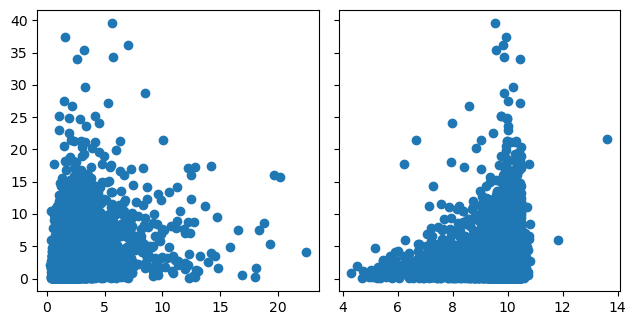

In [ ]:
# CV variance againsts CV absolute errors
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(CVvars_cal[idxs][:-5], abs_errorsCV[idxs][:-5]) # some outliers
axes[1].scatter(mces_cal, abs_errorsCV)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

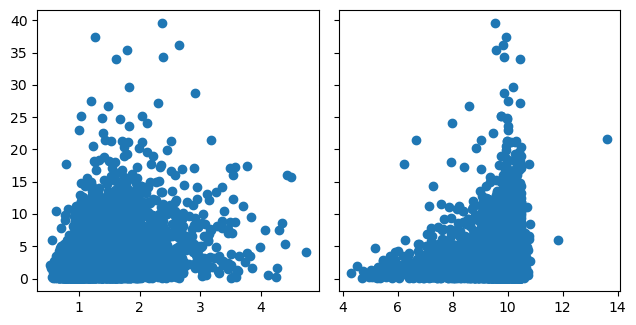

In [47]:
# CV standard devs againsts CV absolute errors
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(CVstds_cal[idxs][:-5], abs_errorsCV[idxs][:-5])
axes[1].scatter(mces_cal, abs_errorsCV)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

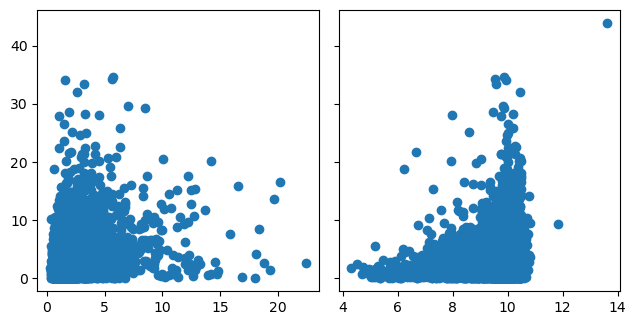

In [48]:
# CV var againsts final GraphCCS abs errors
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(CVvars_cal[idxs][:-5], abs_errors[idxs][:-5])
axes[1].scatter(mces_cal, abs_errors)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

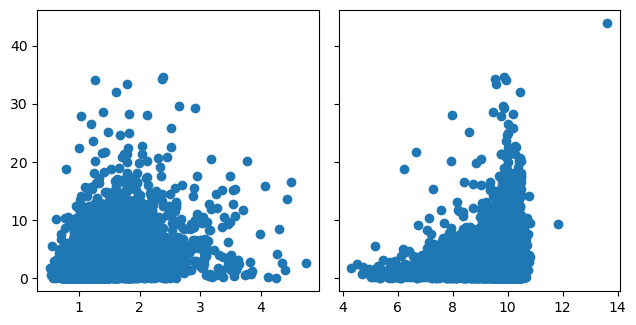

In [49]:
# CV stds againsts final GraphCCS abs errors
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(CVstds_cal[idxs][:-5], abs_errors[idxs][:-5])
axes[1].scatter(mces_cal, abs_errors)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

## Random forest treeSD

In [ ]:
# base


import numpy as np
import pandas as pd
import pickle

from itertools import product
from sklearn.metrics import r2_score
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

In [62]:
with open("final_fold_idxs.pkl", 'rb') as f:
    final_fold = pickle.load(f) # tuple of two arrays with the indexes of METLIN-CCS for the final training and calibration splits
print(f'Size of training set: {final_fold[0].size} --- Size of calibration set: {final_fold[1].size}')

Size of training set: 52236 --- Size of calibration set: 5805


In [63]:
y = pd.read_csv("METLINclean.csv", usecols=['CCS']).to_numpy().flatten()
y_train = y[final_fold[0]]
y_cal = y[final_fold[1]]

X = pd.read_csv('FGPs.csv', index_col=0).to_numpy() # ECFP2 fingerprints for METLIN-CCS with concatenated m/z and one-hot-encoded ion type
print(f'Fingerprint matrix: {X.shape}')
Xtrain = X[final_fold[0]]
Xcal = X[final_fold[1]]

Fingerprint matrix: (58041, 1028)


In [ ]:
n_estimators = [200, 500, 1000]
max_features = [1/3, 'log2', 1.]
min_samples_leaf = [1, 3, 6, 12]

combos = [combo for combo in product(n_estimators, max_features, min_samples_leaf)]

results = []
for combo in combos:
    rf_ccs = RandomForestRegressor(n_estimators=combo[0], max_features=combo[1], min_samples_leaf=combo[2], n_jobs=15)
    rf_ccs.fit(X, y_train)
    rf_hat_train = rf_ccs.predict(Xtrain)
    rf_hat_cal = rf_ccs.predict(Xcal)

    results.append([
        r2_score(y_train, rf_hat_train), 100 * np.percentile(np.abs(y_train - rf_hat_train) / y_train, 90, method = 'nearest'),
        r2_score(y_cal, rf_hat_cal), 100 * np.percentile(np.abs(y_cal - rf_hat_cal) / y_cal, 90, method = 'nearest')
    ])

36it [2:10:52, 218.12s/it]


In [ ]:
results_df = pd.DataFrame(results, index=combos, 
                          columns=['R2train', 'PAEtrain', 'R2cal', 'PAEcal'])

In [18]:
results_df.assign(diff=abs(results_df['PAEtrain'] - results_df['PAEcal'])).sort_values('diff').drop(columns='diff')

,R2train,PAEtrain,R2cal,PAEcal
"(1000, log2, 12)",0.551240,9.464642,0.523619,9.649369
"(200, log2, 12)",0.542652,9.546603,0.515177,9.736666
"(500, log2, 12)",0.546999,9.521066,0.518489,9.719945
"(200, log2, 6)",0.628165,8.604400,0.581098,9.033279
"(500, log2, 6)",0.619632,8.701174,0.572775,9.143427
"(1000, log2, 6)",0.628553,8.591819,0.581894,9.051376
"(500, 0.3333333333333333, 12)",0.889298,4.521561,0.849014,5.274614
"(1000, 0.3333333333333333, 12)",0.889405,4.518227,0.849031,5.296192
"(200, 0.3333333333333333, 12)",0.888871,4.526476,0.848401,5.308655
"(500, log2, 3)",0.721049,7.436687,0.640428,8.340391


In [64]:
rf_ccs = RandomForestRegressor(n_estimators=500, max_features=1/3, min_samples_leaf=12, n_jobs=15)
rf_ccs.fit(Xtrain, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,12
,min_weight_fraction_leaf,0.0
,max_features,0.3333333333333333
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
rfYhat_train = np.asarray([tree.predict(Xtrain) for tree in tqdm(rf_ccs.estimators_)])

100%|██████████| 500/500 [00:51<00:00,  9.79it/s]


In [66]:
treeSD = np.std(rfYhat_train, axis=0, ddof=1)

In [68]:
Utrain = np.load('train_myopicMCES.npy') # training MCES distance matrix 
print(f'Training MCES distance matrix: {Utrain.shape}')
mces_train = np.mean(np.partition(Utrain, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Training MCES distance matrix: (52236, 6668)


In [69]:
y_hat_train = np.load('y_hat_train.npy') # CCS prediction for the final training set from the final GraphCCS model
print(f'Number of final GraphCCS training predictions: {y_hat_train.size}')

Number of final GraphCCS training predictions: 52236


In [70]:
y_hat_train_rf = np.mean(rfYhat_train, axis = 0)

In [71]:
abs_errors = np.abs(y_train - y_hat_train)
abs_errors_rf = np.abs(y_train - y_hat_train_rf)

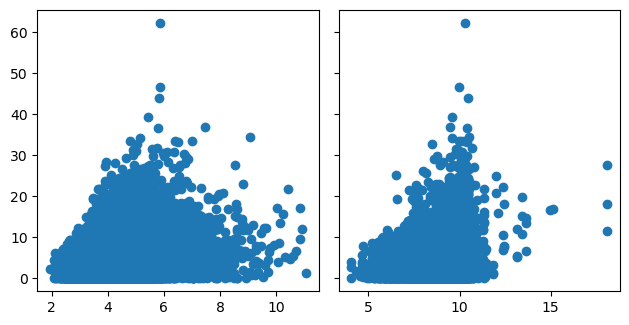

In [72]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(treeSD, abs_errors_rf)
axes[1].scatter(mces_train, abs_errors_rf)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

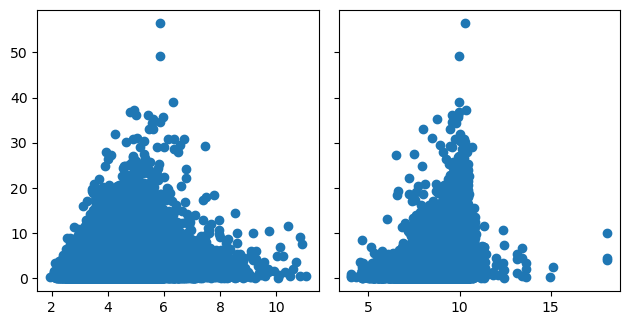

In [73]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(treeSD, abs_errors)
axes[1].scatter(mces_train, abs_errors)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

# Error model

## Random forest regressor on a feature space composed of m/z, cross-validation ensemble standard deviation, CCShat as well as one-hot-encoded ion type

In [74]:
# base


import pickle as pkl
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

In [75]:
Ucal = np.load('CALmyopicMCES.npy') # calibration MCES distance matrix 
print(f'Calibration MCES distance matrix: {Ucal.shape}')

mces_cal = np.mean(np.partition(Ucal, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Calibration MCES distance matrix: (5805, 6668)


In [ ]:
YhatCVcal = np.load('YhatCVcal.npy') # CCS prediction for the final calibrants from the 25 CV models

CVstds_cal = np.std(YhatCVcal, axis=1, ddof=1)

In [77]:
y_hat_cal = np.load('y_hat_cal.npy') # CCS prediction for the final calibrants from the final GraphCCS model
print(f'Number of final GraphCCS calibration predictions: {y_hat_cal.size}')

Number of final GraphCCS calibration predictions: 5805


In [78]:
with open("final_fold_idxs.pkl", 'rb') as f:
    final_fold = pickle.load(f) # tuple of two arrays with the indexes of METLIN-CCS for the final training and calibration splits
print(f'Size of training set: {final_fold[0].size} --- Size of calibration set: {final_fold[1].size}')

ion_info = pd.read_csv('FGPs.csv', index_col=0).to_numpy()[final_fold[1], -4:] # m/z and one-hot-encoded ion type

Size of training set: 52236 --- Size of calibration set: 5805


In [82]:
Xtrain = np.hstack((mces_cal.reshape(-1, 1), CVstds_cal.reshape(-1, 1), y_hat_cal.reshape(-1, 1), ion_info))

In [ ]:
Xtrain.shape

(5805, 7)

In [ ]:
Xtrain[0]

array([  9.2578125 ,   1.27782325, 186.39868164, 348.1319    ,
         0.        ,   1.        ,   0.        ])

In [83]:
y_cal = pd.read_csv("METLINclean.csv", usecols=['CCS']).to_numpy().flatten()[final_fold[1]]
y_train = np.abs(y_cal - y_hat_cal)

In [106]:
rf = RandomForestRegressor(n_estimators=100, min_samples_leaf=6, max_features=1/3, n_jobs=15) 
rf.fit(Xtrain[:-1000], y_train[:-1000])

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,0.3333333333333333
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


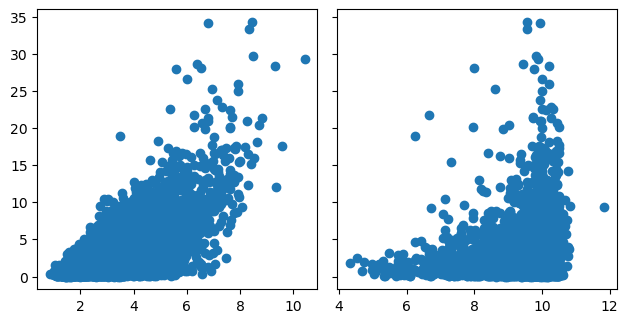

In [107]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(rf.predict(Xtrain[:-1000]), y_train[:-1000])
axes[1].scatter(mces_cal[:-1000], y_train[:-1000])
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

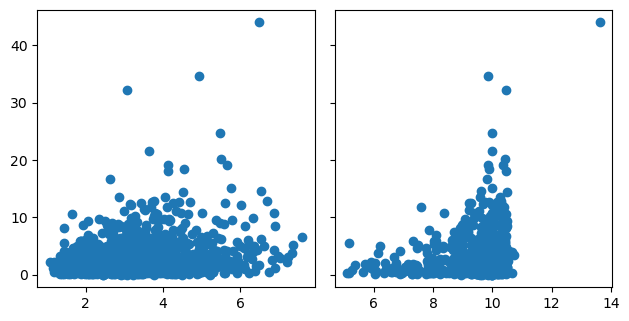

In [108]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(rf.predict(Xtrain[-1000:]), y_train[-1000:])
axes[1].scatter(mces_cal[-1000:], y_train[-1000:])
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

## ECFPs

### Random forest

In [ ]:
# base


import pickle
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

In [ ]:
with open("final_fold_idxs.pkl", 'rb') as f:
    final_fold = pickle.load(f) # tuple of two arrays with the indexes of METLIN-CCS for the final training and calibration splits
print(f'Size of training set: {final_fold[0].size} --- Size of calibration set: {final_fold[1].size}')

ccs = pd.read_csv("METLINclean.csv", usecols=['CCS']).to_numpy().flatten()
X = pd.read_csv('FGPs.csv', index_col=0).to_numpy()


Size of training set: 52236 --- Size of calibration set: 5805


In [ ]:
ccs_hat_train = np.load('y_hat_train.npy')
y_train = np.abs(ccs[final_fold[0]] - ccs_hat_train)
Xtrain = X[final_fold[0]]

In [ ]:
Utrain = np.load('train_myopicMCES.npy') # training MCES distance matrix 
print(f'Training MCES distance matrix: {Utrain.shape}')
mces_train = np.mean(np.partition(Utrain, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Training MCES distance matrix: (52236, 6668)


In [ ]:
ccs_hat_cal = np.load('y_hat_cal.npy')
y_cal = np.abs(ccs[final_fold[1]] - ccs_hat_cal)
Xcal = X[final_fold[1]]

In [ ]:
Ucal = np.load('CALmyopicMCES.npy') # calibration MCES distance matrix 
print(f'Calibration MCES distance matrix: {Ucal.shape}')
mces_cal = np.mean(np.partition(Ucal, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Calibration MCES distance matrix: (5805, 6668)


In [7]:
rf = RandomForestRegressor(n_estimators=500, max_features=1/3, min_samples_leaf=6, n_jobs=15)
rf.fit(Xtrain, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,0.3333333333333333
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


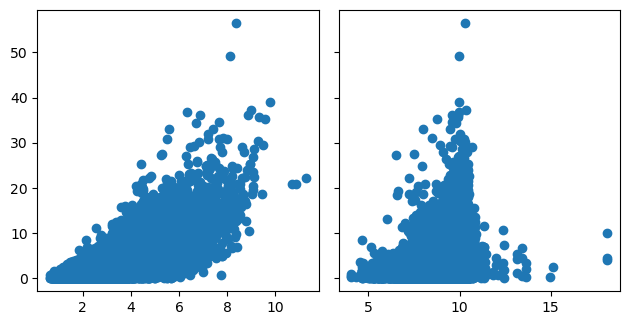

In [10]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(rf.predict(Xtrain), y_train)
axes[1].scatter(mces_train, y_train)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

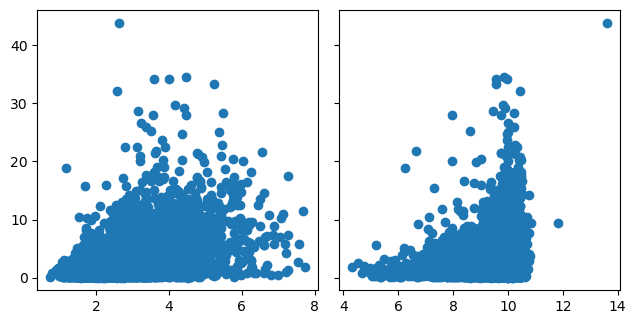

In [16]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(rf.predict(Xcal), y_cal)
axes[1].scatter(mces_cal, y_cal)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

### SVR

In [1]:
# base


import pickle
import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [2]:
with open("final_fold_idxs.pkl", 'rb') as f:
    final_fold = pickle.load(f) # tuple of two arrays with the indexes of METLIN-CCS for the final training and calibration splits
print(f'Size of training set: {final_fold[0].size} --- Size of calibration set: {final_fold[1].size}')

ccs = pd.read_csv("METLINclean.csv", usecols=['CCS']).to_numpy().flatten()
X = pd.read_csv('FGPs.csv', index_col=0).to_numpy()


Size of training set: 52236 --- Size of calibration set: 5805


In [3]:
ccs_hat_train = np.load('y_hat_train.npy')
y_train = np.abs(ccs[final_fold[0]] - ccs_hat_train)
Xtrain = X[final_fold[0]]

In [4]:
Utrain = np.load('train_myopicMCES.npy') # training MCES distance matrix 
print(f'Training MCES distance matrix: {Utrain.shape}')
mces_train = np.mean(np.partition(Utrain, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Training MCES distance matrix: (52236, 6668)


In [5]:
ccs_hat_cal = np.load('y_hat_cal.npy')
y_cal = np.abs(ccs[final_fold[1]] - ccs_hat_cal)
Xcal = X[final_fold[1]]

In [6]:
Ucal = np.load('CALmyopicMCES.npy') # calibration MCES distance matrix 
print(f'Calibration MCES distance matrix: {Ucal.shape}')
mces_cal = np.mean(np.partition(Ucal, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Calibration MCES distance matrix: (5805, 6668)


In [8]:
vthr = VarianceThreshold()
Xtrain_trans = vthr.fit_transform(Xtrain)
scaler = StandardScaler()
Xtrain_trans = scaler.fit_transform(Xtrain_trans)

In [9]:
Xcal_trans = scaler.transform(vthr.transform(Xcal))

In [10]:
svr = SVR()
svr.fit(Xtrain_trans, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


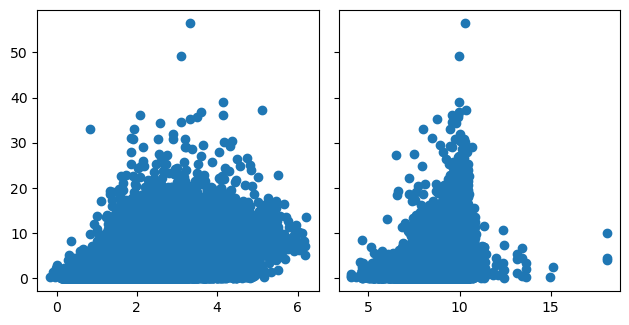

In [11]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(svr.predict(Xtrain_trans), y_train)
axes[1].scatter(mces_train, y_train)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

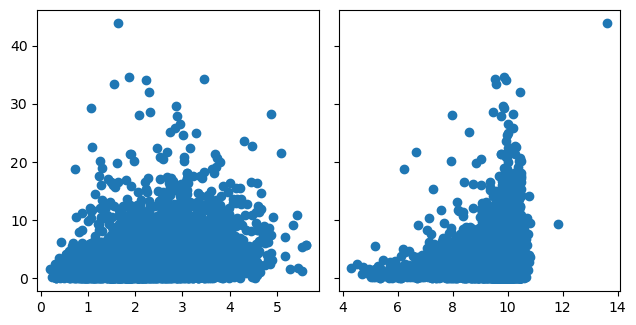

In [12]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(svr.predict(Xcal_trans), y_cal)
axes[1].scatter(mces_cal, y_cal)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

### Feed-forward neural network

In [10]:
# Keras


import pickle
import numpy as np
import pandas as pd

import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

GPUs: []


In [3]:
with open("final_fold_idxs.pkl", 'rb') as f:
    final_fold = pickle.load(f) # tuple of two arrays with the indexes of METLIN-CCS for the final training and calibration splits
print(f'Size of training set: {final_fold[0].size} --- Size of calibration set: {final_fold[1].size}')

ccs = pd.read_csv("METLINclean.csv", usecols=['CCS']).to_numpy().flatten()
X = pd.read_csv('FGPs.csv', index_col=0).to_numpy()

Size of training set: 52236 --- Size of calibration set: 5805


In [4]:
ccs_hat_train = np.load('y_hat_train.npy')
y_train = np.abs(ccs[final_fold[0]] - ccs_hat_train)
Xtrain = X[final_fold[0]]

In [5]:
Utrain = np.load('train_myopicMCES.npy') # training MCES distance matrix 
print(f'Training MCES distance matrix: {Utrain.shape}')
mces_train = np.mean(np.partition(Utrain, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Training MCES distance matrix: (52236, 6668)


In [6]:
ccs_hat_cal = np.load('y_hat_cal.npy')
y_cal = np.abs(ccs[final_fold[1]] - ccs_hat_cal)
Xcal = X[final_fold[1]]

In [7]:
Ucal = np.load('CALmyopicMCES.npy') # calibration MCES distance matrix 
print(f'Calibration MCES distance matrix: {Ucal.shape}')
mces_cal = np.mean(np.partition(Ucal, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Calibration MCES distance matrix: (5805, 6668)


In [8]:
model = Sequential(
    [   
        Input(shape=(Xtrain.shape[1],)),
        Dense(1028, activation='relu'),
        Dense(512,  activation='relu'),
        Dense(32,   activation='relu'),
        Dense(1,    activation='linear')
    ]
)
model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=1e-4))
history = model.fit(Xtrain, y_train, batch_size = 128, epochs = 70)

Epoch 1/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 9.3762
Epoch 2/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8.5105
Epoch 3/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8.2403
Epoch 4/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 8.3070
Epoch 5/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 8.2472
Epoch 6/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.9704
Epoch 7/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.8644
Epoch 8/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.7651
Epoch 9/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.9064
Epoch 10/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.6182
Epoch 11/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.7634
Epoch 12/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 8.0161
Epoch 13/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.8234
Epoch 14/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.7585
Epoch 15/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - lo

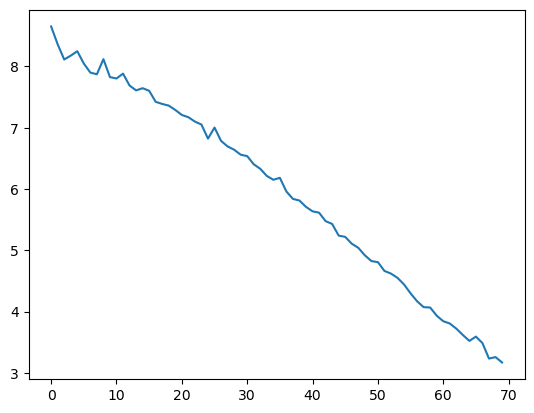

In [12]:
plt.plot(history.history['loss'])

1633/1633 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


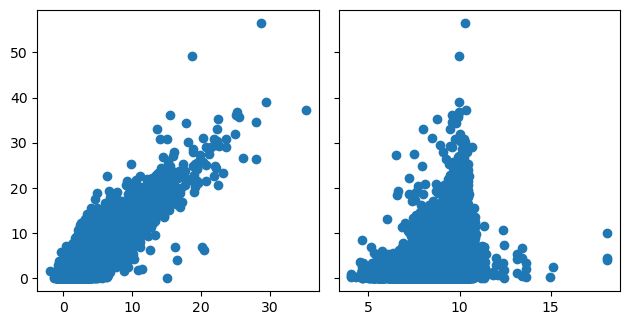

In [13]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(model.predict(Xtrain).flatten(), y_train)
axes[1].scatter(mces_train, y_train)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


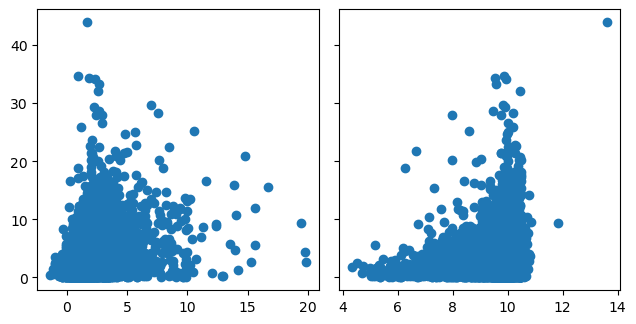

In [15]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(model.predict(Xcal).flatten(), y_cal)
axes[1].scatter(mces_cal, y_cal)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

## GraphCCS embedding

In [1]:
# Keras


import pickle
import numpy as np
import pandas as pd

import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

GPUs: []


In [2]:
with open("final_fold_idxs.pkl", 'rb') as f:
    final_fold = pickle.load(f) # tuple of two arrays with the indexes of METLIN-CCS for the final training and calibration splits
print(f'Size of training set: {final_fold[0].size} --- Size of calibration set: {final_fold[1].size}')

ccs = pd.read_csv("METLINclean.csv", usecols=['CCS']).to_numpy().flatten()
X = np.load('embeddings.npy')
print(f'Size of the embedding matrix: {X.shape}')

Size of training set: 52236 --- Size of calibration set: 5805
Size of the embedding matrix: (58041, 400)


In [3]:
ccs_hat_train = np.load('y_hat_train.npy')
y_train = np.abs(ccs[final_fold[0]] - ccs_hat_train)
Xtrain = X[final_fold[0]]

In [4]:
Utrain = np.load('train_myopicMCES.npy') # training MCES distance matrix 
print(f'Training MCES distance matrix: {Utrain.shape}')
mces_train = np.mean(np.partition(Utrain, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Training MCES distance matrix: (52236, 6668)


In [5]:
ccs_hat_cal = np.load('y_hat_cal.npy')
y_cal = np.abs(ccs[final_fold[1]] - ccs_hat_cal)
Xcal = X[final_fold[1]]

In [6]:
Ucal = np.load('CALmyopicMCES.npy') # calibration MCES distance matrix 
print(f'Calibration MCES distance matrix: {Ucal.shape}')
mces_cal = np.mean(np.partition(Ucal, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Calibration MCES distance matrix: (5805, 6668)


### SVR

In [7]:
vthr = VarianceThreshold()
Xtrain_trans = vthr.fit_transform(Xtrain)
scaler = StandardScaler()
Xtrain_trans = scaler.fit_transform(Xtrain_trans)

In [8]:
Xcal_trans = scaler.transform(vthr.transform(Xcal))

In [9]:
svr = SVR()
svr.fit(Xtrain_trans, y_train)

SVR()

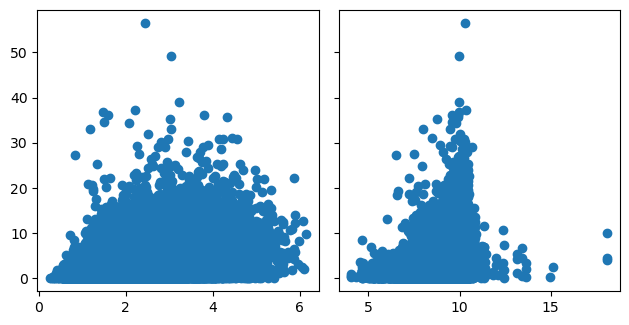

In [10]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(svr.predict(Xtrain_trans), y_train)
axes[1].scatter(mces_train, y_train)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

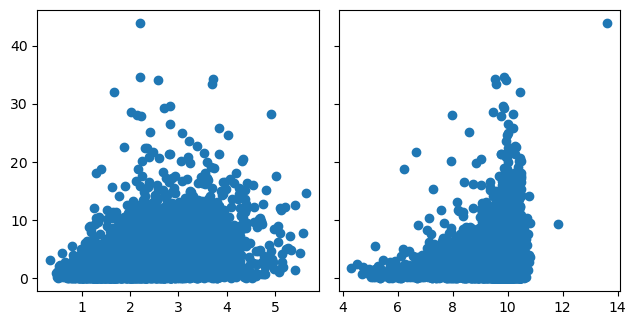

In [11]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(svr.predict(Xcal_trans), y_cal)
axes[1].scatter(mces_cal, y_cal)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

### FFN

In [13]:
model = Sequential(
    [   
        Input(shape=(Xtrain.shape[1],)),
        Dense(400, activation='relu', kernel_regularizer=regularizers.l2(1e-2)),
        Dense(256,  activation='relu', kernel_regularizer=regularizers.l2(1e-2)),
        Dense(128,   activation='relu', kernel_regularizer=regularizers.l2(1e-2)),
        Dense(64,   activation='relu', kernel_regularizer=regularizers.l2(1e-2)),
        Dense(1,    activation='linear')
    ]
)
model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=1e-4))
history = model.fit(Xtrain, y_train, batch_size = 128, epochs = 70)

Epoch 1/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17.7224
Epoch 2/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13.2895
Epoch 3/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11.8347
Epoch 4/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11.5087
Epoch 5/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10.9052
Epoch 6/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10.7464
Epoch 7/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10.2679
Epoch 8/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.9675
Epoch 9/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10.2829
Epoch 10/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.8562
Epoch 11/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.9228
Epoch 12/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.6934
Epoch 13/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.3013
Epoch 14/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.2574
Epoch 15/70
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/s

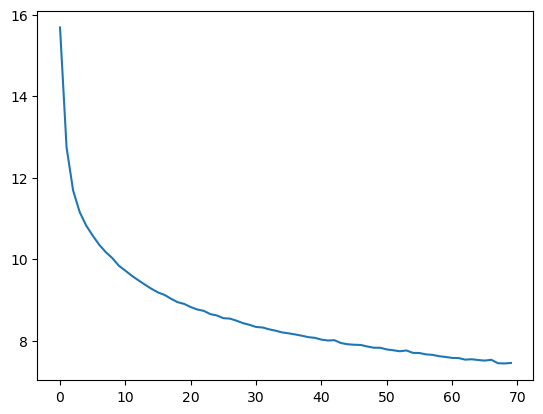

In [14]:
plt.plot(history.history['loss'])

1633/1633 ━━━━━━━━━━━━━━━━━━━━ 1s 653us/step


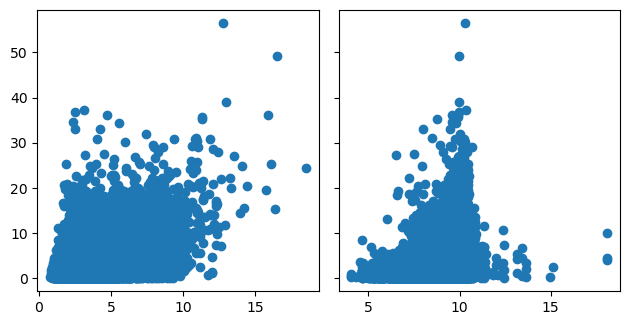

In [15]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(model.predict(Xtrain).flatten(), y_train)
axes[1].scatter(mces_train, y_train)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step


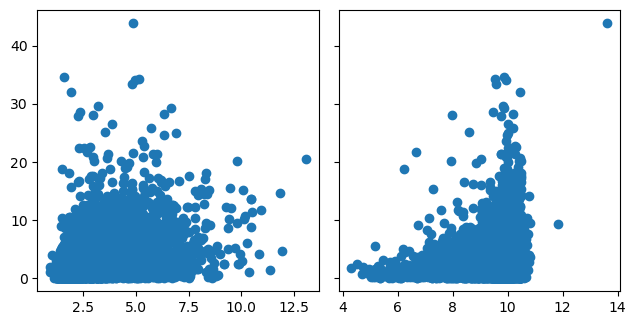

In [16]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(model.predict(Xcal).flatten(), y_cal)
axes[1].scatter(mces_cal, y_cal)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

### RF

In [17]:
rf = RandomForestRegressor(n_estimators=500, max_features=1/3, min_samples_leaf=6, n_jobs=15)
rf.fit(Xtrain, y_train)

RandomForestRegressor(max_features=0.3333333333333333, min_samples_leaf=6,
                      n_estimators=500, n_jobs=15)

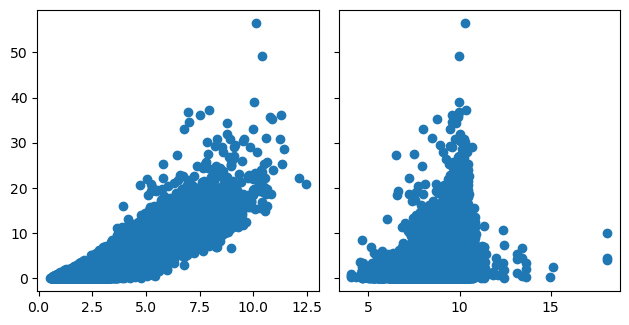

In [18]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(rf.predict(Xtrain), y_train)
axes[1].scatter(mces_train, y_train)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

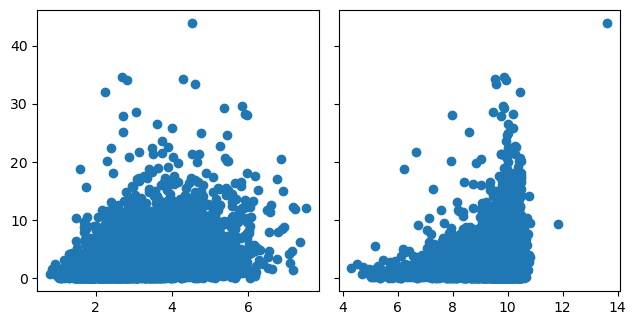

In [19]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(rf.predict(Xcal), y_cal)
axes[1].scatter(mces_cal, y_cal)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

## Potential SVR

In [1]:
# cvxpy


import pickle as pickle
import numpy as np
import pandas as pd

from PSVR import *

import matplotlib.pyplot as plt

In [19]:
with open("final_fold_idxs.pkl", 'rb') as f:
    final_fold = pickle.load(f) # tuple of two arrays with the indexes of METLIN-CCS for the final training and calibration splits
print(f'Size of training set: {final_fold[0].size} --- Size of calibration set: {final_fold[1].size}')

ccs_train = pd.read_csv("METLINclean.csv", usecols=['CCS']).to_numpy().flatten()[final_fold[0]]
ccs_hat_train = np.load('y_hat_train.npy')

Size of training set: 52236 --- Size of calibration set: 5805


In [29]:
y_train = np.abs(ccs_train - ccs_hat_train)

In [4]:
Xtrain = np.load('ionMCEStrain.npy').astype(np.float32) # this is an MCES distance matrix
# calculated between ion graphs
# it contains the distances between all final training ions of GraphCCS and a subsample of it (the corresponding METLIN-CCS indexes are
# under finalPSVRidxs.npy)
Xtrain.shape

(52236, 5224)

In [5]:
Xtrain

array([[22. , 16. , 11. , ..., 20. , 17. , 14. ],
       [19.5, 17.5, 21.5, ..., 21.5, 10.5, 13.5],
       [17. , 13. , 13. , ..., 22. , 12. , 20. ],
       ...,
       [16. , 16. , 15. , ..., 30. , 19. , 11. ],
       [21. , 20. , 15. , ..., 13. , 15. , 22. ],
       [16. , 13. , 14. , ..., 21. , 11. , 19. ]],
      shape=(52236, 5224), dtype=float32)

In [8]:
sum(Xtrain == 0).sum()

np.int64(5224)

In [10]:
stds = np.std(Xtrain, axis=0, ddof=1)

In [11]:
sum(stds <= 5), sum(stds > 5)

(np.int64(4365), np.int64(859))

In [9]:
Xtrain_norm = np.load('ionMCEStrain_norm.npy').astype(np.float32) # this is a normalized MCES distance matrix
# calculated between ion graphs
# it contains the distances between all final training ions of GraphCCS and a subsample of it (the corresponding METLIN-CCS indexes are
# under finalPSVRidxs.npy)
Xtrain_norm.shape

(52236, 5224)

In [18]:
stds_norm = np.std(Xtrain_norm, axis=0, ddof=1)
sum(stds_norm <= 0.1), sum(stds_norm > 0.1)

(np.int64(5000), np.int64(224))

### For predicting CCS

In [25]:
psvr = PSVR(C = 100, epsilon=0.01, stdev_threshold=5)
psvr.fit(Xtrain, ccs_train)

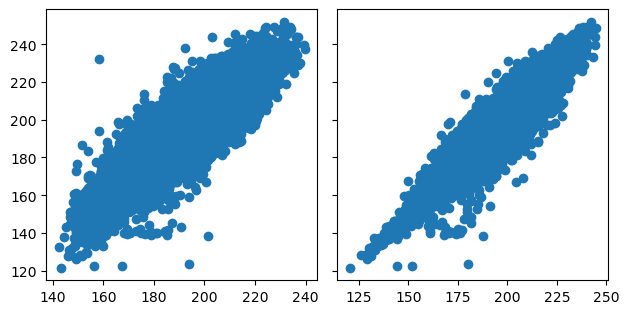

In [26]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(psvr.predict(Xtrain), ccs_train)
axes[1].scatter(ccs_hat_train, ccs_train)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

In [27]:
psvr = PSVR(C = 100, epsilon=0.01, stdev_threshold=0.1)
psvr.fit(Xtrain_norm, ccs_train)

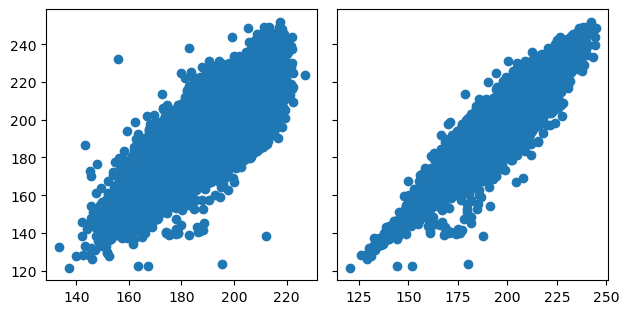

In [28]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(psvr.predict(Xtrain_norm), ccs_train)
axes[1].scatter(ccs_hat_train, ccs_train)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

### For predicting errors

In [31]:
Utrain = np.load('train_myopicMCES.npy') # training MCES distance matrix 
print(f'Training MCES distance matrix: {Utrain.shape}')
mces_train = np.mean(np.partition(Utrain, kth = 46, axis = 1)[:, :46], axis=1).astype(np.float64)

Training MCES distance matrix: (52236, 6668)


In [30]:
psvr = PSVR(C = 100, epsilon=0.01, stdev_threshold=5)
psvr.fit(Xtrain, y_train)

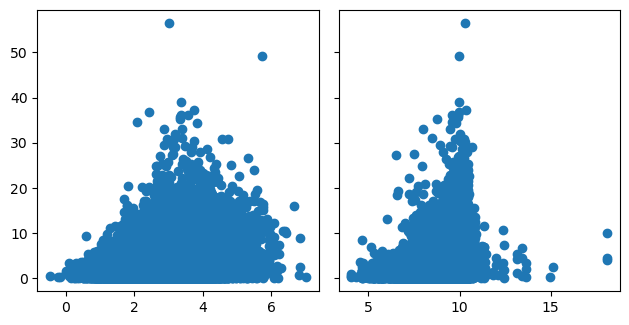

In [32]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(psvr.predict(Xtrain), y_train)
axes[1].scatter(mces_train, y_train)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

In [33]:
psvr = PSVR(C = 100, epsilon=0.01, stdev_threshold=0.1)
psvr.fit(Xtrain_norm, y_train)

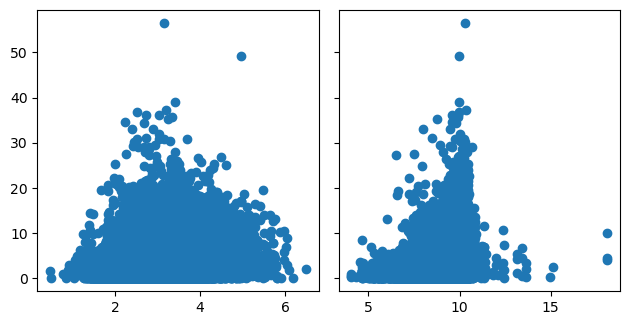

In [34]:
fig, axes = plt.subplots(1, 2, sharey=True)
axes[0].scatter(psvr.predict(Xtrain_norm), y_train)
axes[1].scatter(mces_train, y_train)
for ax in axes:
    ax.set_box_aspect(1)
plt.tight_layout()
plt.show()